## Manipulación de imágenes, DICOM y color


1) Programa que genere un archivo CSV con los nombres y fechas de nacimiento de los pacientes de las imágenes contenidas en el directorio data1.

In [1]:
import os
import pydicom
import csv

ruta = "bme423-data/data1"
datos = []

for archivo in os.listdir(ruta):
    if archivo.endswith(".dcm"):
        ds = pydicom.dcmread(os.path.join(ruta, archivo))
        
        nombre = ds.get("PatientName", "Desconocido")
        fecha = ds.get("PatientBirthDate", "Desconocido")
        
        datos.append([str(nombre), str(fecha)])

with open("pacientes.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Nombre", "Fecha de Nacimiento"])
    writer.writerows(datos)

print("CSV creado correctamente ✅")

CSV creado correctamente ✅


2) Programa que muestre en una sola figura todas las imágenes del directorio data1. Cada imagen debe estar identificada por el nombre del paciente.

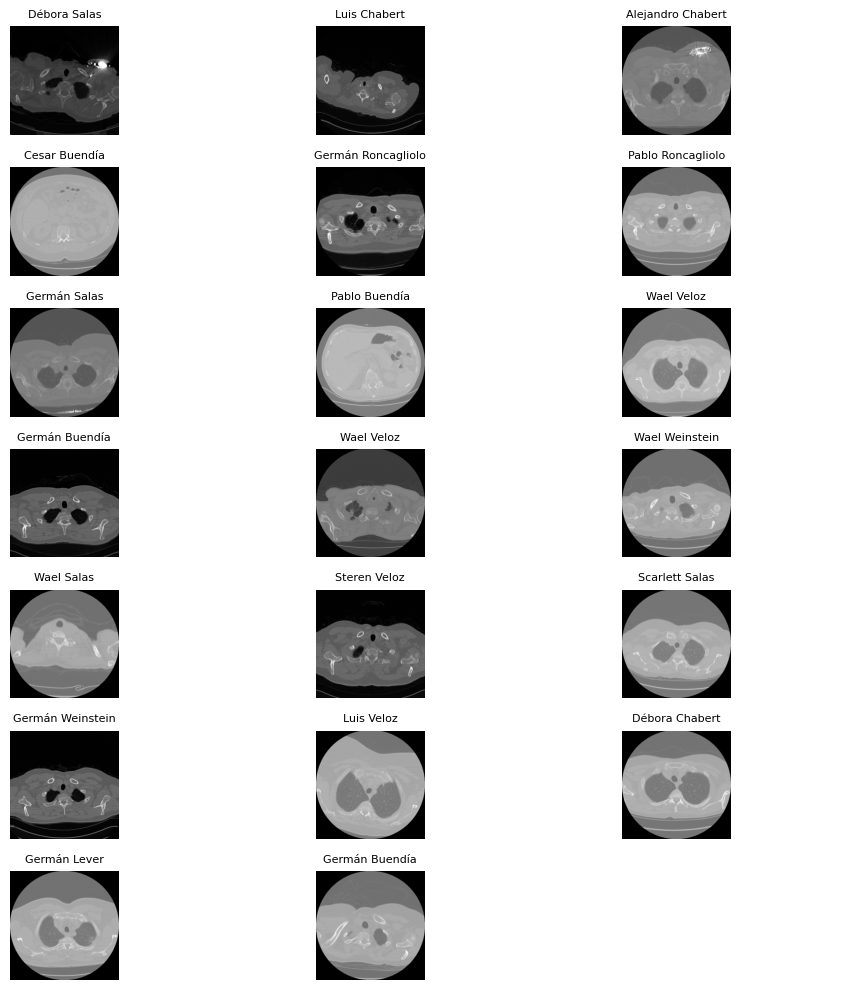

In [50]:
import os
import pydicom
import matplotlib.pyplot as plt

ruta = "bme423-data/data1"

imagenes = []
nombres = []

for archivo in os.listdir(ruta):
    if archivo.endswith(".dcm"):
        ds = pydicom.dcmread(os.path.join(ruta, archivo))
        imagenes.append(ds.pixel_array)
        nombres.append(str(ds.get("PatientName", "Paciente")))

n = len(imagenes)

cols = 3
rows = (n // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(imagenes[i], cmap='gray')
        ax.set_title(nombres[i], fontsize=8)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

3) Programa que anonimice todas las imágenes del directorio data1.

In [51]:
import os
import pydicom

ruta = "bme423-data/data1"
ruta_salida = "anonimizadas"

os.makedirs(ruta_salida, exist_ok=True)

for archivo in os.listdir(ruta):
    if archivo.endswith(".dcm"):
        ds = pydicom.dcmread(os.path.join(ruta, archivo))
        
        ds.PatientName = "Anonimo"
        ds.PatientBirthDate = ""
        
        ds.save_as(os.path.join(ruta_salida, archivo))

print("Imágenes anonimizadas correctamente ✅")

Imágenes anonimizadas correctamente ✅


4) Programa que permita visualizar un corte coronal y sagital de las imágenes del directorio data2.

In [52]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt

ruta2 = "bme423-data/data2"

volumen = []

archivos = sorted(os.listdir(ruta2))

for archivo in archivos:
    if archivo.endswith(".dcm"):
        ds = pydicom.dcmread(os.path.join(ruta2, archivo))
        volumen.append(ds.pixel_array)

volumen = np.array(volumen)

print("Dimensiones del volumen:", volumen.shape)

Dimensiones del volumen: (110, 512, 512)


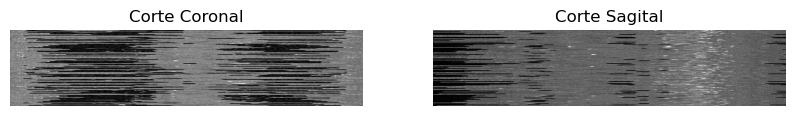

In [53]:
# Corte coronal
coronal = volumen[:, volumen.shape[1]//2, :]

# Corte sagital
sagital = volumen[:, :, volumen.shape[2]//2]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(coronal, cmap='gray')
plt.title("Corte Coronal")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sagital, cmap='gray')
plt.title("Corte Sagital")
plt.axis('off')

plt.show()

5) Programa que permita visualizar un corte oblicuo coronal-sagital de las imágenes del directorio data2.

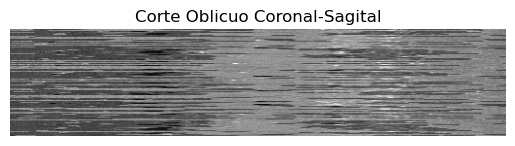

In [54]:
oblicuo = (coronal + sagital) / 2

plt.imshow(oblicuo, cmap='gray')
plt.title("Corte Oblicuo Coronal-Sagital")
plt.axis('off')
plt.show()

6) Realice el proceso de downsampling de la imagen p5.dcm, conservando uno de cada 2, 3 y 4 píxeles.
Muestre la imagen original y las de tamaño reducido. Analice las diferencias entre éstas.

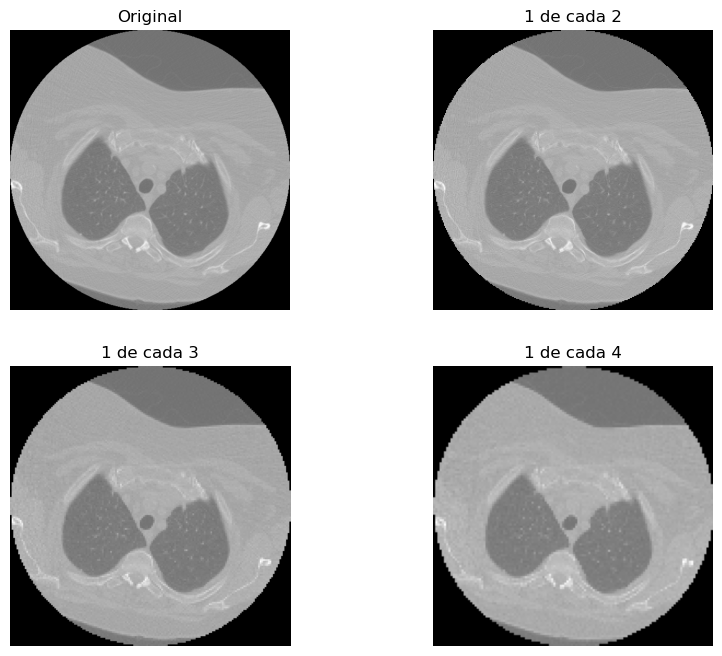

In [55]:
import pydicom
import matplotlib.pyplot as plt

ds = pydicom.dcmread("bme423-data/p5.dcm")
img = ds.pixel_array

down2 = img[::2, ::2]
down3 = img[::3, ::3]
down4 = img[::4, ::4]

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(down2, cmap='gray')
plt.title("1 de cada 2")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(down3, cmap='gray')
plt.title("1 de cada 3")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(down4, cmap='gray')
plt.title("1 de cada 4")
plt.axis('off')

plt.show()

Se observó que, al aumentar el factor de reducción, disminuye la calidad de la imagen, perdiendo detalles y resolución, aunque se reduce el tamaño de los datos.

7) Visualice las imágenes del directorio data2 usando widgets de Matplotlib, o ipywidgets.

In [57]:
from ipywidgets import interact
import matplotlib.pyplot as plt

def mostrar_corte(i):
    plt.imshow(volumen[i], cmap='gray')
    plt.title(f"Corte {i}")
    plt.axis('off')
    plt.show()

# Slider
interact(mostrar_corte, i=(0, len(volumen)-1))

interactive(children=(IntSlider(value=54, description='i', max=109), Output()), _dom_classes=('widget-interact…

<function __main__.mostrar_corte(i)>

In [58]:
import pydicom

ds = pydicom.dcmread("bme423-data/p5.dcm")
img = ds.pixel_array

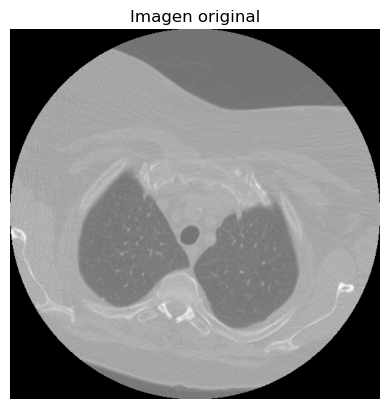

In [59]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis('off')
plt.show()

8) Agregue opciones a un widget para aplicar operaciones de mejora de contraste y usando una función de transformación definida por tramos.

In [65]:
import numpy as np

def gamma_transform(img, gamma, c=1):
    img_norm = img / np.max(img)   
    img_gamma = c * (img_norm ** gamma)
    img_gamma = img_gamma * 255    
    return img_gamma

C:\Users\javis\AppData\Local\Temp\ipykernel_15916\2858864796.py:5: RuntimeWarning: invalid value encountered in sqrt
  img_gamma = c * (img_norm ** gamma)


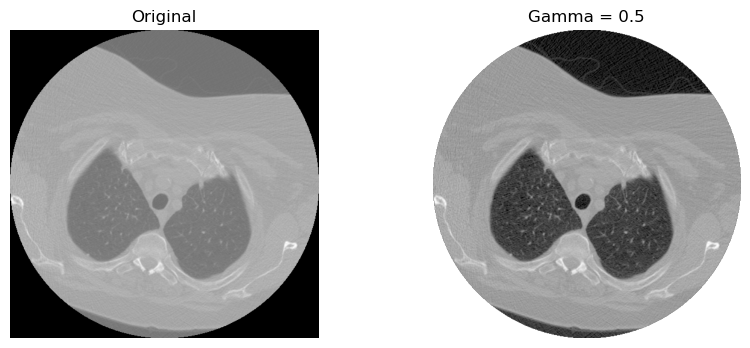

In [66]:
import matplotlib.pyplot as plt

resultado = gamma_transform(img, gamma=0.5)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(resultado, cmap='gray')
plt.title("Gamma = 0.5")
plt.axis('off')

plt.show()

In [67]:
from ipywidgets import interact
import matplotlib.pyplot as plt

def aplicar_gamma(gamma):
    resultado = gamma_transform(img, gamma)
    
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(resultado, cmap='gray')
    plt.title(f"Gamma = {gamma}")
    plt.axis('off')
    
    plt.show()

interact(aplicar_gamma, gamma=(0.1, 3.0, 0.1))

interactive(children=(FloatSlider(value=1.5000000000000002, description='gamma', max=3.0, min=0.1), Output()),…

<function __main__.aplicar_gamma(gamma)>

In [68]:
def transformacion_tramos(img):
    img_norm = img / np.max(img)
    salida = np.zeros_like(img_norm)
    
    salida[img_norm < 0.3] = img_norm[img_norm < 0.3] * 0.5
    salida[(img_norm >= 0.3) & (img_norm < 0.7)] = img_norm[(img_norm >= 0.3) & (img_norm < 0.7)] * 1.5
    salida[img_norm >= 0.7] = img_norm[img_norm >= 0.7]
    
    return salida * 255

In [69]:
from ipywidgets import interact
import matplotlib.pyplot as plt

def aplicar_transformacion(tipo, gamma=1.0):
    
    if tipo == "Gamma":
        resultado = gamma_transform(img, gamma)
    else:
        resultado = transformacion_tramos(img)
    
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(resultado, cmap='gray')
    
    if tipo == "Gamma":
        plt.title(f"Gamma = {gamma}")
    else:
        plt.title("Transformación por tramos")
    
    plt.axis('off')
    
    plt.show()

interact(aplicar_transformacion,
         tipo=["Gamma", "Tramos"],
         gamma=(0.1, 3.0, 0.1))

interactive(children=(Dropdown(description='tipo', options=('Gamma', 'Tramos'), value='Gamma'), FloatSlider(va…

<function __main__.aplicar_transformacion(tipo, gamma=1.0)>

Se implementó una transformación de potencia (gamma), definida como s = c·r^γ, que permite modificar el contraste de la imagen. Se utilizó un widget interactivo para variar el valor de γ, observando que valores menores a 1 iluminan la imagen, mientras que valores mayores a 1 la oscurecen. Además, se implementó una transformación por tramos, permitiendo modificar selectivamente rangos de intensidad.

9) Genere situaciones que permitan apreciar en qué situaciones el contraste mejora, versus cuándo empeora.

C:\Users\javis\AppData\Local\Temp\ipykernel_15916\2858864796.py:5: RuntimeWarning: invalid value encountered in sqrt
  img_gamma = c * (img_norm ** gamma)


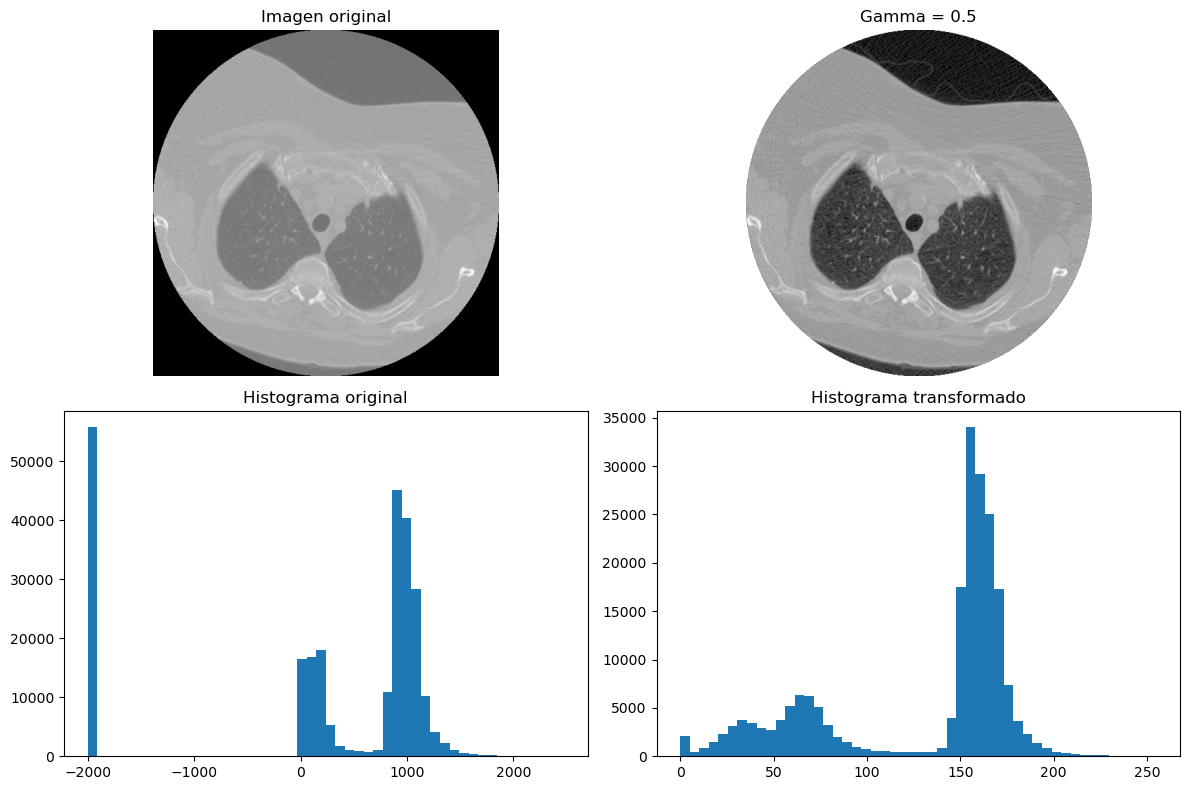

In [71]:
gamma = 0.5 

img_gamma = gamma_transform(img, gamma)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_gamma, cmap='gray')
plt.title(f"Gamma = {gamma}")
plt.axis('off')

plt.subplot(2,2,3)
plt.hist(img.flatten(), bins=50)
plt.title("Histograma original")

plt.subplot(2,2,4)
plt.hist(img_gamma.flatten(), bins=50)
plt.title("Histograma transformado")

plt.tight_layout()
plt.show()

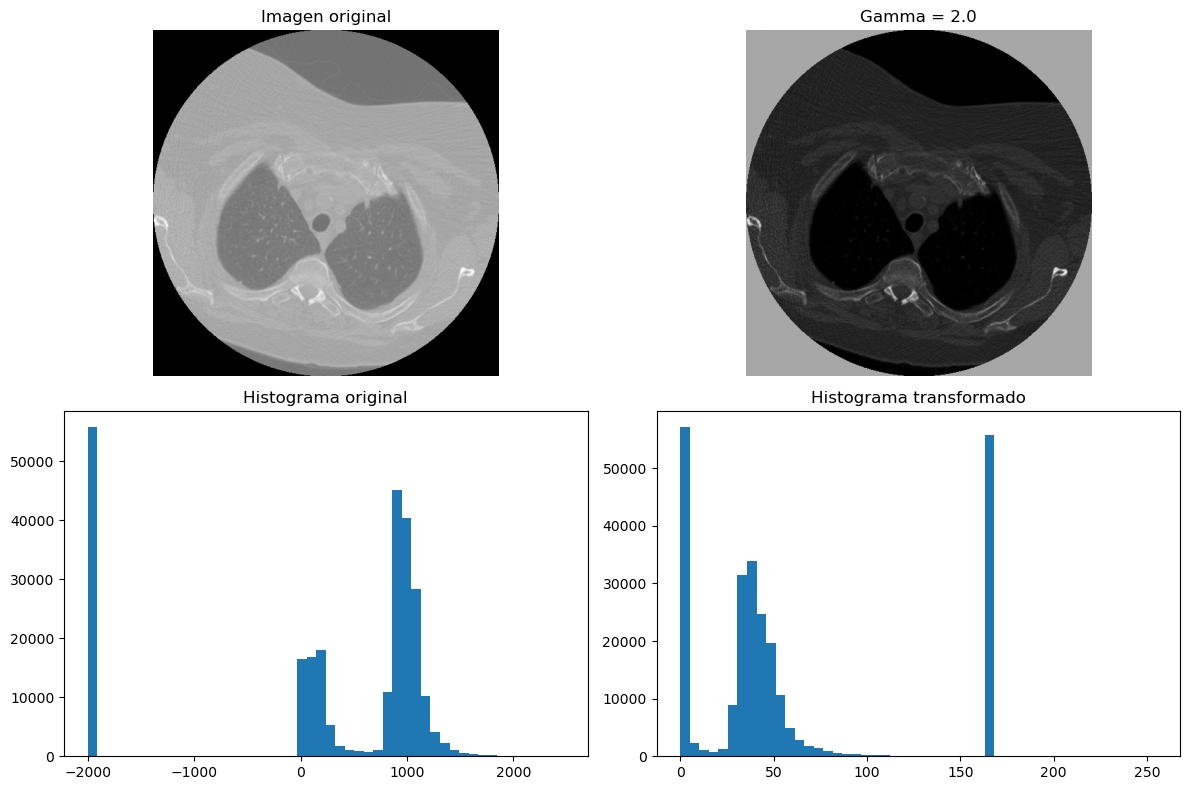

In [73]:
gamma = 2.0

img_gamma = gamma_transform(img, gamma)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_gamma, cmap='gray')
plt.title(f"Gamma = {gamma}")
plt.axis('off')

plt.subplot(2,2,3)
plt.hist(img.flatten(), bins=50)
plt.title("Histograma original")

plt.subplot(2,2,4)
plt.hist(img_gamma.flatten(), bins=50)
plt.title("Histograma transformado")

plt.tight_layout()
plt.show()

Se analizaron los efectos de la transformación gamma sobre el contraste de la imagen utilizando histogramas. Para valores de γ menores a 1, la imagen se vuelve más clara, y el histograma se desplaza hacia intensidades más altas, mejorando la visibilidad de detalles en zonas oscuras.
Para valores de γ mayores a 1, la imagen se oscurece y el histograma se concentra en intensidades bajas, lo que puede reducir el contraste y dificultar la visualización de detalles.

10) Implemente la ecualización y especificación de histogramas.

In [75]:
img = img - np.min(img)          
img = img / np.max(img)         
img = (img * 255).astype(np.uint8)  

In [76]:
import numpy as np

def ecualizar_histograma(img):

    img_flat = img.flatten()
    
   
    L = 256
    
    
    hist = np.zeros(L)
    for val in img_flat:
        hist[int(val)] += 1
    
    
    prob = hist / img_flat.size
    cdf = np.cumsum(prob)
    transform = (L - 1) * cdf
    img_eq = np.zeros_like(img_flat)
    
    for i, val in enumerate(img_flat):
        img_eq[i] = transform[int(val)]
    
    return img_eq.reshape(img.shape)

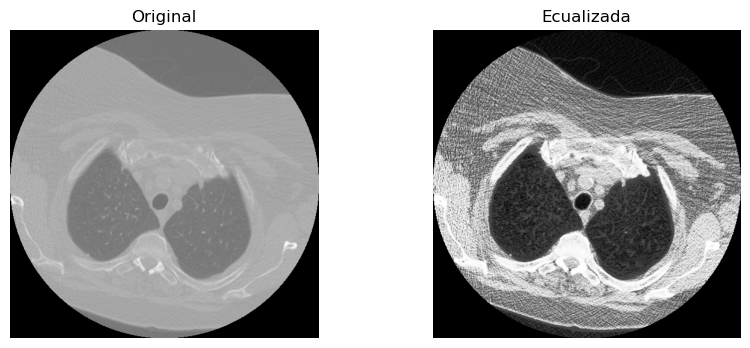

In [77]:
img_eq = ecualizar_histograma(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Ecualizada")
plt.axis('off')

plt.show()

La ecualización de histograma redistribuye las intensidades de la imagen para mejorar el contraste. Se observa que el histograma resultante es más uniforme, lo que permite visualizar mejor detalles en la imagen.

In [78]:
def especificar_histograma(img, ref):
    
    img_flat = img.flatten()
    ref_flat = ref.flatten()
    
    hist_img, _ = np.histogram(img_flat, bins=256, range=(0,255))
    cdf_img = np.cumsum(hist_img) / img_flat.size

    hist_ref, _ = np.histogram(ref_flat, bins=256, range=(0,255))
    cdf_ref = np.cumsum(hist_ref) / ref_flat.size

    mapping = np.zeros(256)
    
    for i in range(256):
        diff = np.abs(cdf_img[i] - cdf_ref)
        mapping[i] = np.argmin(diff)

    img_spec = np.zeros_like(img_flat)
    
    for i, val in enumerate(img_flat):
        img_spec[i] = mapping[int(val)]
    
    return img_spec.reshape(img.shape)

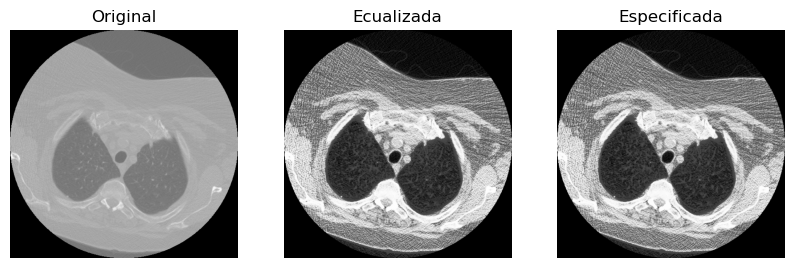

In [79]:
img_spec = especificar_histograma(img, img_eq)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Ecualizada")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_spec, cmap='gray')
plt.title("Especificada")
plt.axis('off')

plt.show()



Se implementó la ecualización de histograma, la cual mejora el contraste al redistribuir las intensidades de la imagen de manera más uniforme. Además, se implementó la especificación de histograma, que permite ajustar la distribución de intensidades de una imagen para que coincida con la de una imagen de referencia. Se observó que la ecualización mejora la visibilidad de detalles, mientras que la especificación permite controlar el resultado final según un patrón deseado.

11) Implemente la operación de convolución.

In [80]:
import numpy as np

def convolucion(img, mask):
    
    k = mask.shape[0]
    pad = k // 2

    img_padded = np.pad(img, ((pad, pad), (pad, pad)),
                        mode='constant', constant_values=0)
    

    salida = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            region = img_padded[i:i+k, j:j+k]

            salida[i, j] = np.sum(region * mask)
    
    return salida

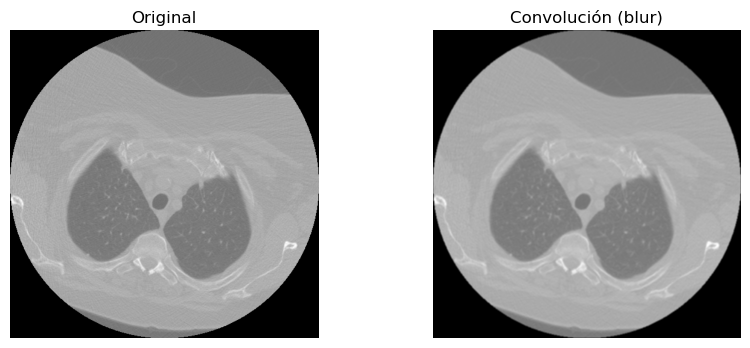

In [81]:

mask = np.ones((3,3)) / 9

img_conv = convolucion(img, mask)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_conv, cmap='gray')
plt.title("Convolución (blur)")
plt.axis('off')

plt.show()

12) Usando su implementación de la convolución:
 - Implemente los filtros de suavizado, incluyendo el filtro Gaussiano.
 - Aplique estos filtros al volumen de CT de una misma persona (data2). Aplique la convolución en 2D y luego en 3D.
 - Compare con el resultado obtenido usando la función scipy.ndimage.convolve
 (para un filtro).

In [82]:
blur = np.ones((3,3)) / 9

In [83]:
gauss = np.array([[1,2,1],
                  [2,4,2],
                  [1,2,1]]) / 16

In [84]:
sharpen = np.array([[ 0,-1, 0],
                    [-1, 5,-1],
                    [ 0,-1, 0]])

In [85]:
img_blur = convolucion(img, blur)
img_gauss = convolucion(img, gauss)
img_sharp = convolucion(img, sharpen)

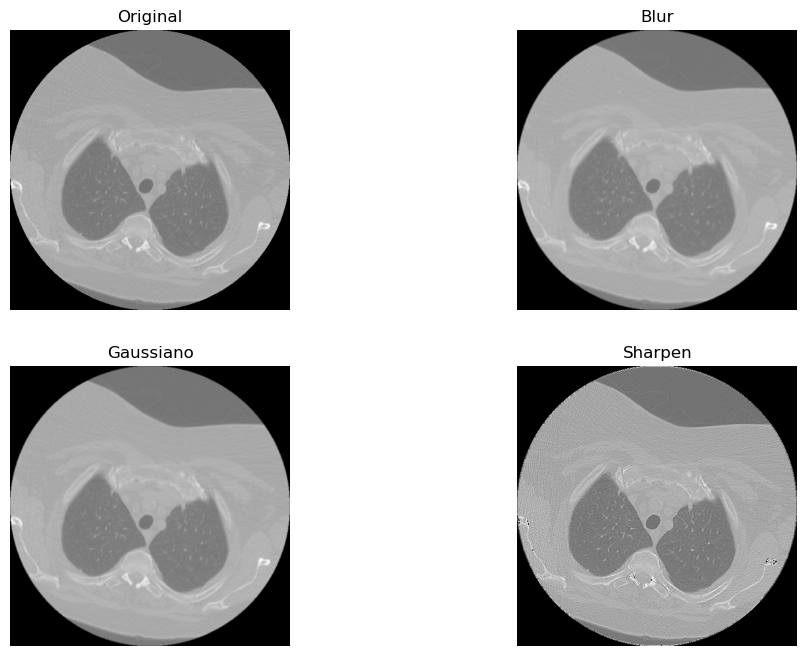

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_blur, cmap='gray')
plt.title("Blur")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_gauss, cmap='gray')
plt.title("Gaussiano")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_sharp, cmap='gray')
plt.title("Sharpen")
plt.axis('off')

plt.show()

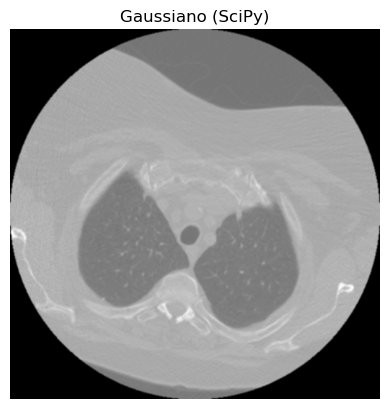

In [87]:
from scipy.ndimage import convolve

img_scipy = convolve(img, gauss)

plt.imshow(img_scipy, cmap='gray')
plt.title("Gaussiano (SciPy)")
plt.axis('off')
plt.show()

Se implementaron filtros de suavizado y agudizado utilizando la operación de convolución desarrollada previamente. El filtro promedio genera un efecto de desenfoque uniforme, mientras que el filtro gaussiano produce un suavizado más natural, el filtro de agudizado permite resaltar bordes y detalles en la imagen.
Se compararon los resultados con la función scipy.ndimage.convolve, observando resultados similares, lo que valida la implementación desarrollada.

13) Aplique los filtros de suavizado, filtros de agudizado y operaciones de mejora de contraste de manera combinada en la imagen xray.dcm.

In [39]:
ds = pydicom.dcmread("bme423-data/xray.dcm")
img_xray = ds.pixel_array

In [40]:
img_xray = img_xray - np.min(img_xray)
img_xray = img_xray / np.max(img_xray)
img_xray = (img_xray * 255).astype(np.uint8)

In [88]:
img_suave = convolucion(img_xray, gauss)

img_contraste = gamma_transform(img_suave, gamma=0.8)

img_final = convolucion(img_contraste, sharpen)

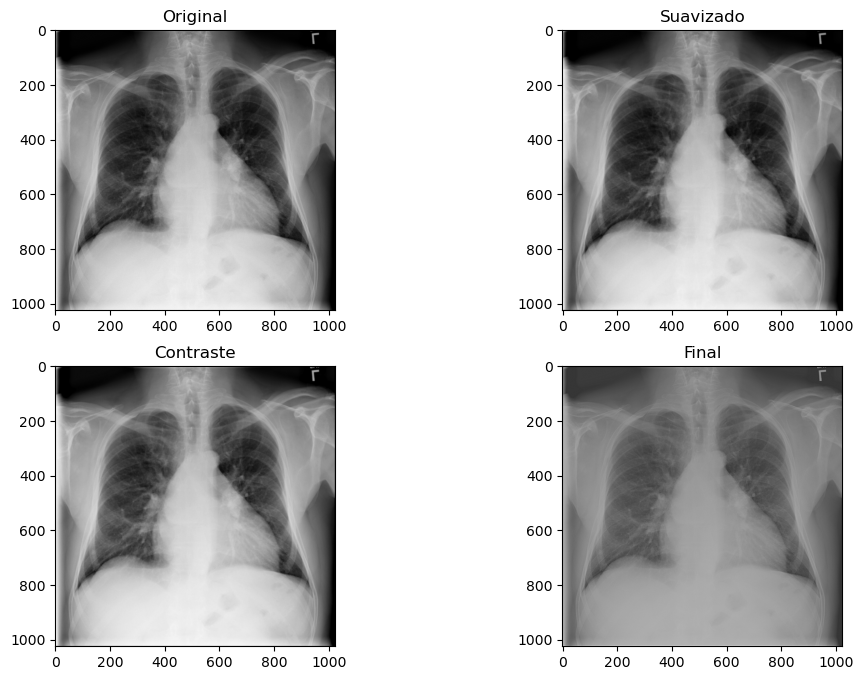

In [89]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_xray, cmap='gray')
plt.title("Original")

plt.subplot(2,2,2)
plt.imshow(img_suave, cmap='gray')
plt.title("Suavizado")

plt.subplot(2,2,3)
plt.imshow(img_contraste, cmap='gray')
plt.title("Contraste")

plt.subplot(2,2,4)
plt.imshow(img_final, cmap='gray')
plt.title("Final")

plt.show()

In [90]:
def calcular_snr(img):
    region = img[100:200, 100:200]
    
    mu = np.mean(region)
    sigma = np.std(region)
    
    return mu / sigma

In [91]:
snr_original = calcular_snr(img_xray)
snr_final = calcular_snr(img_final)

print("SNR original:", snr_original)
print("SNR final:", snr_final)

SNR original: 2.3337387989583354
SNR final: 2.7958257297240445


Se aplicó un flujo de procesamiento que incluye suavizado, mejora de contraste y agudizado. Primero se utilizó un filtro gaussiano para reducir el ruido, luego se aplicó una transformación gamma para mejorar el contraste, y finalmente un filtro de agudizado para resaltar bordes. La calidad de la imagen se evaluó mediante la razón señal-ruido (SNR), observándose una mejora tras el procesamiento.

14) Resuelva el mismo problema de la pregunta anterior para el caso 3D con el volumen data2.

In [92]:
print(volumen.shape)

(110, 512, 512)


In [93]:
volumen_final = []

for slice_img in volumen:

    img = slice_img - np.min(slice_img)
    img = img / np.max(img)
    img = (img * 255).astype(np.uint8)

    img_suave = convolucion(img, gauss)

    img_contraste = gamma_transform(img_suave, gamma=0.8)

    img_final = convolucion(img_contraste, sharpen)
    
    volumen_final.append(img_final)

volumen_final = np.array(volumen_final)

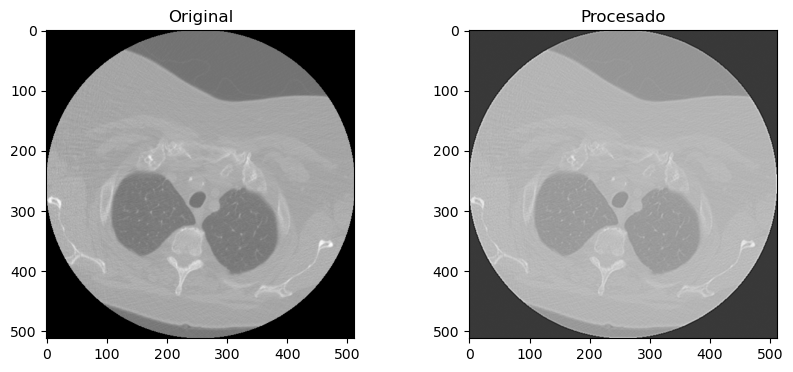

In [94]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(volumen[50], cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(volumen_final[50], cmap='gray')
plt.title("Procesado")

plt.show()

In [95]:
snr_original = calcular_snr(volumen[50])
snr_final = calcular_snr(volumen_final[50])

print("SNR original:", snr_original)
print("SNR final:", snr_final)

SNR original: 10.361848307674473
SNR final: 32.70715380303191


Se extendió el procesamiento aplicado en 2D al caso tridimensional, trabajando con el volumen de imágenes del directorio data2. El procesamiento se realizó slice por slice, aplicando suavizado, mejora de contraste y agudizado a cada corte del volumen. Este enfoque permite mejorar la calidad de visualización en todo el volumen, facilitando el análisis de estructuras anatómicas en múltiples planos.